# Assignment 4: Axial Dispersion and Backmixing in a Tubular Reactor

## Aim of the study

In this assignment, the behaviour of a non-ideal tubular reactor is investigated. In contrast to an ideal plug-flow reactor, a real tubular reactor can show axial backmixing. This means that the concentration profile is not only determined by convective transport in the flow direction, but also by axial dispersion along the reactor length.

The reactor considered in this assignment has a length of $10~\mathrm{m}$ and a diameter of $32~\mathrm{mm}$. It is fed from an upstream section with a diameter of $150~\mathrm{mm}$. The volumetric flow rate is $1~\mathrm{L\,s^{-1}}$, and the inlet gas contains component \(A\) with a concentration of $100~\mathrm{mol\,m^{-3}}$. Component \(A\) is converted to product \(B\).

The main objective is to implement the axial-dispersion model as a boundary value problem and to compare it with the ideal plug-flow reactor model. The influence of backmixing is investigated by changing the axial dispersion coefficient and describing the results with the Bodenstein number. Finally, a CSTR cascade is implemented and compared with the dispersion model at selected reactor positions.

The following reaction is considered:

$$
\mathrm{A \rightarrow B}
$$

For the first implementation, a first-order rate law is used:

$$
r = k c_A
$$



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp, solve_bvp
from IPython.display import display, Markdown, Math, HTML

pd.set_option("display.max_colwidth", 120)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "lines.linewidth": 2
})


def conversion(c_A, c_A_in):
    """
    Calculate conversion of component A.
    
    Parameters
    ----------
    c_A : float or array
        Local concentration of component A.
    c_A_in : float
        Inlet concentration of component A.
        
    Returns
    -------
    X_A : float or array
        Conversion of component A.
    """
    return (c_A_in - c_A) / c_A_in


def show_dataframe(df, title=None, digits=4):
    """
    Display a pandas DataFrame in a clean report format.
    """
    if title is not None:
        display(Markdown(f"### {title}"))
        
    display(
        df.round(digits).style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#f2f2f2"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("border", "1px solid #cccccc"),
                ("padding", "6px")
            ]},
            {"selector": "td", "props": [
                ("text-align", "left"),
                ("border", "1px solid #dddddd"),
                ("padding", "6px")
            ]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("width", "100%")
            ]}
        ])
    )

## 1. Problem definition and modelling approach

The assignment deals with a tubular reactor in which component A is converted to product B. The reaction is treated as irreversible.

$$
\mathrm{A \rightarrow B}
$$

For the first model implementation, first-order kinetics are assumed.

$$
r = k c_A
$$

The ideal plug-flow reactor model is first implemented as an initial value problem. This model neglects axial dispersion and is used as a reference case. The material balances for the ideal PFR are written as follows.

$$
u \frac{dc_A}{dz} = -k c_A
$$

$$
u \frac{dc_B}{dz} = k c_A
$$

In these equations, u is the superficial velocity in the reactor, z is the axial reactor coordinate, c_A and c_B are the concentrations of components A and B, and k is the first-order rate constant.

In the axial-dispersion model, an additional second derivative term is included. This term describes axial spreading and backmixing along the reactor length.

$$
u \frac{dc_i}{dz}
=
D_{ax}\frac{d^2 c_i}{dz^2}
+
\sum_j \nu_{i,j} r_j
$$

For the reaction A to B, the species balances become:

$$
u \frac{dc_A}{dz}
=
D_{ax}\frac{d^2 c_A}{dz^2}
-
k c_A
$$

$$
u \frac{dc_B}{dz}
=
D_{ax}\frac{d^2 c_B}{dz^2}
+
k c_A
$$

Because the axial-dispersion model contains second derivatives with respect to the reactor coordinate z, it cannot be solved only from inlet initial values. Boundary conditions are required at the inlet and at the outlet. Therefore, the axial-dispersion model is implemented as a boundary value problem.

The strength of axial dispersion is described by the Bodenstein number.

$$
Bo = \frac{uL}{D_{ax}}
$$

A high Bodenstein number corresponds to weak axial dispersion and behaviour close to an ideal PFR. A low Bodenstein number corresponds to stronger backmixing and therefore stronger deviation from ideal plug-flow behaviour.

The assignment gives a reactor length of 10 m, a reactor diameter of 32 mm, an upstream pipe diameter of 150 mm, a volumetric flow rate of 1 L/s, and an inlet concentration of 100 mol/m3 for component A. It also recommends starting with a first-order reaction model.

Since no numerical value of the rate constant is specified in the task statement, k = 0.2 1/s is selected as a reference value for the first implementation. This value gives an intermediate conversion and therefore allows the differences between the ideal PFR, the axial-dispersion model and the CSTR cascade to be clearly visible.

In [4]:
display(Markdown("## 2. Reactor data and basic calculations"))

display(Markdown("### Reaction system"))
display(Math(r"\mathrm{A \rightarrow B}"))

display(Markdown("### First-order rate law used for the first implementation"))
display(Math(r"r = k\,c_A"))

# Given reactor and feed data
L = 10.0                       # reactor length, m
d_R = 32e-3                    # reactor diameter, m
d_up = 150e-3                  # upstream pipe diameter, m
V_dot = 1.0e-3                 # volumetric flow rate, m3/s, from 1 L/s
c_A_in = 100.0                 # inlet concentration of A, mol/m3
c_B_in = 0.0                   # inlet concentration of B, mol/m3

# First implementation: first-order kinetics
# This value is selected as a reference value because the task statement does not provide k.
k = 0.2                        # rate constant, s^-1
reaction_order = 1.0

# Cross-sectional areas
A_R = np.pi * d_R**2 / 4
A_up = np.pi * d_up**2 / 4

# Superficial velocities
u = V_dot / A_R
u_up = V_dot / A_up

# Mean residence time in the reactor
tau = L / u

display(Markdown("### Geometrical relations"))

display(Math(r"A_R=\frac{\pi d_R^2}{4}"))
display(Math(r"A_{up}=\frac{\pi d_{up}^2}{4}"))

display(Markdown("### Flow relations"))

display(Math(r"u=\frac{\dot{V}}{A_R}"))
display(Math(r"u_{up}=\frac{\dot{V}}{A_{up}}"))
display(Math(r"\tau=\frac{L}{u}"))

display(Markdown("### Calculated reactor quantities"))

reactor_table_html = rf"""
<table>
    <tr>
        <th>Quantity</th>
        <th>Symbol</th>
        <th>Value</th>
        <th>Unit</th>
    </tr>
    <tr>
        <td>Reactor length</td>
        <td>$L$</td>
        <td>{L:.4g}</td>
        <td>$\mathrm{{m}}$</td>
    </tr>
    <tr>
        <td>Reactor diameter</td>
        <td>$d_R$</td>
        <td>{d_R:.4g}</td>
        <td>$\mathrm{{m}}$</td>
    </tr>
    <tr>
        <td>Upstream pipe diameter</td>
        <td>$d_{{up}}$</td>
        <td>{d_up:.4g}</td>
        <td>$\mathrm{{m}}$</td>
    </tr>
    <tr>
        <td>Volumetric flow rate</td>
        <td>$\dot{{V}}$</td>
        <td>{V_dot:.4g}</td>
        <td>$\mathrm{{m^3\,s^{{-1}}}}$</td>
    </tr>
    <tr>
        <td>Reactor cross-sectional area</td>
        <td>$A_R$</td>
        <td>{A_R:.4e}</td>
        <td>$\mathrm{{m^2}}$</td>
    </tr>
    <tr>
        <td>Upstream cross-sectional area</td>
        <td>$A_{{up}}$</td>
        <td>{A_up:.4e}</td>
        <td>$\mathrm{{m^2}}$</td>
    </tr>
    <tr>
        <td>Reactor superficial velocity</td>
        <td>$u$</td>
        <td>{u:.4g}</td>
        <td>$\mathrm{{m\,s^{{-1}}}}$</td>
    </tr>
    <tr>
        <td>Upstream superficial velocity</td>
        <td>$u_{{up}}$</td>
        <td>{u_up:.4g}</td>
        <td>$\mathrm{{m\,s^{{-1}}}}$</td>
    </tr>
    <tr>
        <td>Mean residence time</td>
        <td>$\tau$</td>
        <td>{tau:.4g}</td>
        <td>$\mathrm{{s}}$</td>
    </tr>
    <tr>
        <td>Inlet concentration of A</td>
        <td>$c_{{A,in}}$</td>
        <td>{c_A_in:.4g}</td>
        <td>$\mathrm{{mol\,m^{{-3}}}}$</td>
    </tr>
    <tr>
        <td>Inlet concentration of B</td>
        <td>$c_{{B,in}}$</td>
        <td>{c_B_in:.4g}</td>
        <td>$\mathrm{{mol\,m^{{-3}}}}$</td>
    </tr>
    <tr>
        <td>Reaction order</td>
        <td>$n$</td>
        <td>{reaction_order:.4g}</td>
        <td>$-$</td>
    </tr>
    <tr>
        <td>Reference rate constant</td>
        <td>$k$</td>
        <td>{k:.4g}</td>
        <td>$\mathrm{{s^{{-1}}}}$</td>
    </tr>
</table>
"""

display(HTML(reactor_table_html))

display(Markdown("### Numerical substitution"))

display(Math(
    rf"A_R=\frac{{\pi(0.032\,\mathrm{{m}})^2}}{{4}}"
    rf"={A_R:.4e}\,\mathrm{{m^2}}"
))

display(Math(
    rf"A_{{up}}=\frac{{\pi(0.150\,\mathrm{{m}})^2}}{{4}}"
    rf"={A_up:.4e}\,\mathrm{{m^2}}"
))

display(Math(
    rf"u=\frac{{1.0\cdot10^{{-3}}\,\mathrm{{m^3\,s^{{-1}}}}}}{{{A_R:.4e}\,\mathrm{{m^2}}}}"
    rf"={u:.4f}\,\mathrm{{m\,s^{{-1}}}}"
))

display(Math(
    rf"u_{{up}}=\frac{{1.0\cdot10^{{-3}}\,\mathrm{{m^3\,s^{{-1}}}}}}{{{A_up:.4e}\,\mathrm{{m^2}}}}"
    rf"={u_up:.4f}\,\mathrm{{m\,s^{{-1}}}}"
))

display(Math(
    rf"\tau=\frac{{10\,\mathrm{{m}}}}{{{u:.4f}\,\mathrm{{m\,s^{{-1}}}}}}"
    rf"={tau:.4f}\,\mathrm{{s}}"
))

display(Markdown(
    "The calculated superficial velocity in the reactor is much higher than in the upstream section "
    "because the reactor diameter is significantly smaller than the upstream pipe diameter. "
    "The resulting mean residence time in the reactor is approximately "
    f"{tau:.2f} s. This residence time is used as the characteristic time scale for the ideal PFR, "
    "the axial-dispersion model and the CSTR-cascade comparison."
))

## 2. Reactor data and basic calculations

### Reaction system

<IPython.core.display.Math object>

### First-order rate law used for the first implementation

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The calculated superficial velocity in the reactor is much higher than in the upstream section because the reactor diameter is significantly smaller than the upstream pipe diameter. The resulting mean residence time in the reactor is approximately 8.04 s. This residence time is used as the characteristic time scale for the ideal PFR, the axial-dispersion model and the CSTR-cascade comparison.

## 3. Ideal plug-flow reactor model as initial value problem

The ideal plug-flow reactor is used as the reference model. In this model, axial dispersion is neglected. Therefore, transport occurs only by convection in the axial direction.

### Model equations

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

For a first-order reaction in an ideal PFR with constant velocity, the concentration profile of component A can also be calculated analytically.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Ideal PFR outlet values and analytical validation

Model,Residence time / s,"c_A,out / mol m^-3","c_B,out / mol m^-3","X_A,out / -",Max. error c_A / mol m^-3,Max. error X_A / -
Ideal PFR IVP,8.042500,20.018900,79.981100,0.799800,0.000000,0.000000


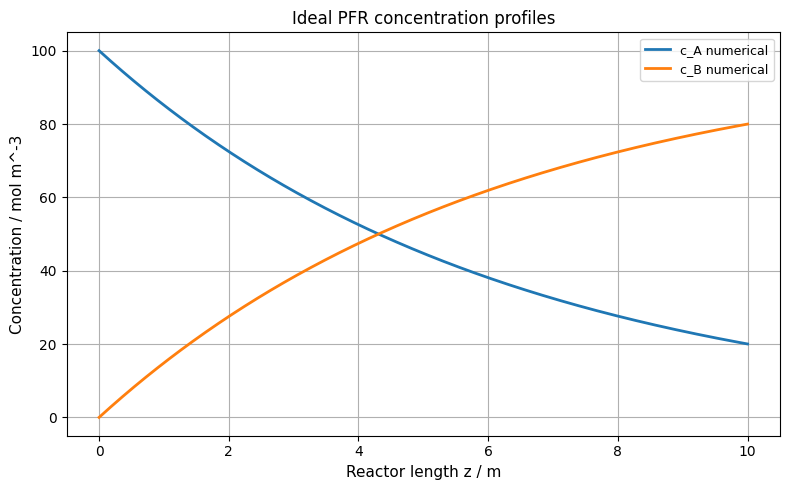

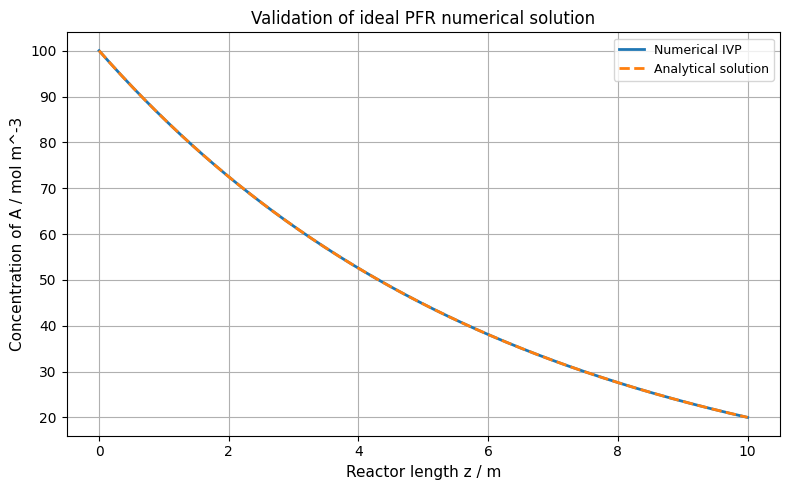

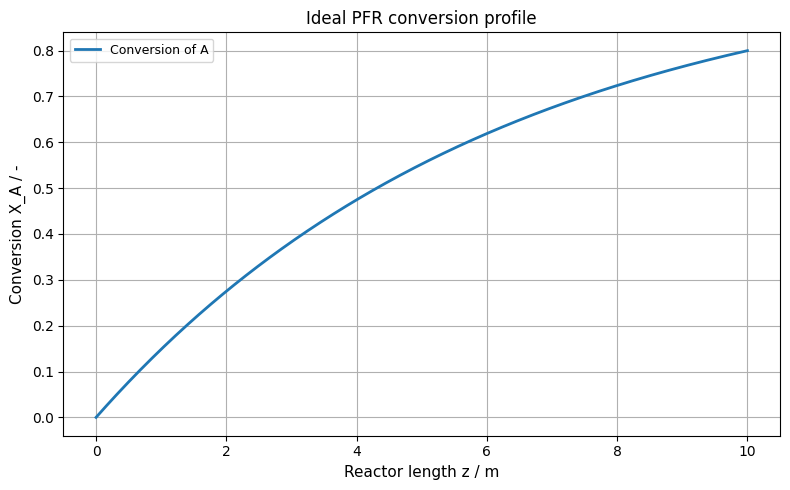

### Interpretation of the ideal PFR result

The ideal PFR gives an outlet conversion of approximately 0.800. This result is used as the reference case for the later axial-dispersion model. The numerical IVP solution agrees with the analytical first-order PFR solution, which confirms that the basic reactor model and numerical implementation are correct.

In [5]:
display(Markdown("## 3. Ideal plug-flow reactor model as initial value problem"))

display(Markdown(
    "The ideal plug-flow reactor is used as the reference model. "
    "In this model, axial dispersion is neglected. Therefore, transport occurs only by convection in the axial direction."
))

display(Markdown("### Model equations"))

display(Math(r"u\frac{dc_A}{dz}=-k c_A"))

display(Math(r"u\frac{dc_B}{dz}=k c_A"))

display(Markdown(
    "The model is an initial value problem because the concentrations at the reactor inlet are known. "
    "Starting from the inlet values, the concentration profiles are integrated along the reactor length."
))

display(Markdown("### Initial conditions"))

display(Math(r"c_A(z=0)=c_{A,in}"))

display(Math(r"c_B(z=0)=c_{B,in}=0"))


def pfr_ivp_rhs(z, y, k, u):
    """
    Right-hand side of the ideal plug-flow reactor model.

    y[0] = c_A
    y[1] = c_B
    """
    c_A, c_B = y

    r = k * c_A

    dc_A_dz = -r / u
    dc_B_dz = r / u

    return [dc_A_dz, dc_B_dz]


# Axial grid for evaluation
z_eval = np.linspace(0, L, 500)

# Solve ideal PFR model
ivp_solution = solve_ivp(
    fun=lambda z, y: pfr_ivp_rhs(z, y, k, u),
    t_span=(0, L),
    y0=[c_A_in, c_B_in],
    t_eval=z_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-11
)

if not ivp_solution.success:
    raise RuntimeError(ivp_solution.message)

# Store results
pfr_df = pd.DataFrame({
    "z / m": ivp_solution.t,
    "c_A / mol m^-3": ivp_solution.y[0],
    "c_B / mol m^-3": ivp_solution.y[1],
})

pfr_df["X_A / -"] = conversion(pfr_df["c_A / mol m^-3"], c_A_in)

display(Markdown("### Analytical first-order solution"))

display(Markdown(
    "For a first-order reaction in an ideal PFR with constant velocity, "
    "the concentration profile of component A can also be calculated analytically."
))

display(Math(r"c_A(z)=c_{A,in}\exp\left(-\frac{kz}{u}\right)"))

display(Math(r"X_A(z)=1-\frac{c_A(z)}{c_{A,in}}"))

# Analytical solution
pfr_df["c_A analytical / mol m^-3"] = c_A_in * np.exp(-k * pfr_df["z / m"] / u)
pfr_df["X_A analytical / -"] = conversion(pfr_df["c_A analytical / mol m^-3"], c_A_in)

# Error between numerical and analytical solution
max_error_cA = np.max(
    np.abs(pfr_df["c_A / mol m^-3"] - pfr_df["c_A analytical / mol m^-3"])
)

max_error_X = np.max(
    np.abs(pfr_df["X_A / -"] - pfr_df["X_A analytical / -"])
)

# Summary table
pfr_summary = pd.DataFrame([
    {
        "Model": "Ideal PFR IVP",
        "Residence time / s": tau,
        "c_A,out / mol m^-3": pfr_df["c_A / mol m^-3"].iloc[-1],
        "c_B,out / mol m^-3": pfr_df["c_B / mol m^-3"].iloc[-1],
        "X_A,out / -": pfr_df["X_A / -"].iloc[-1],
        "Max. error c_A / mol m^-3": max_error_cA,
        "Max. error X_A / -": max_error_X,
    }
])

show_dataframe(pfr_summary, "Ideal PFR outlet values and analytical validation")

# Concentration profiles
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="c_A numerical"
)
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_B / mol m^-3"],
    label="c_B numerical"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration / mol m^-3")
plt.title("Ideal PFR concentration profiles")
plt.legend()
plt.tight_layout()
plt.show()

# Numerical vs analytical validation
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="Numerical IVP"
)
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A analytical / mol m^-3"],
    "--",
    label="Analytical solution"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("Validation of ideal PFR numerical solution")
plt.legend()
plt.tight_layout()
plt.show()

# Conversion profile
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["X_A / -"],
    label="Conversion of A"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title("Ideal PFR conversion profile")
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown("### Interpretation of the ideal PFR result"))

display(Markdown(
    f"The ideal PFR gives an outlet conversion of approximately {pfr_df['X_A / -'].iloc[-1]:.3f}. "
    "This result is used as the reference case for the later axial-dispersion model. "
    "The numerical IVP solution agrees with the analytical first-order PFR solution, "
    "which confirms that the basic reactor model and numerical implementation are correct."
))